# 02 - Meteogram quicklook (raw NetCDF): NW & NF

Open individual meteogram NetCDF files (one at a time, no concatenation)
and plot time–height cross-sections of bulk droplet (NW) and ice-crystal
(NF) number concentrations.

In [1]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: 22182-mbp-2.local
is_server: False


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from utilities.plotting import get_extpar_data, create_new_jet3, create_fade_cmap, make_pastel
from utilities.meteogram_io import discover_meteogram_files

## Configuration

In [8]:
cs_run = "cs-eriswil__20260211_194236"

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
    extpar_path = root / "COS_in" / "extPar_Eriswil_50x40.nc"
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run
    extpar_path = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_50x40.nc"

nc_files = sorted(data_dir.glob("M_??_??_*.nc"))
print(f"Found {len(nc_files)} NetCDF meteogram files in {data_dir}:")
for f in nc_files:
    print(f"  {f.name}")

print(f"\nExtPar: {extpar_path.name}")

Found 12 NetCDF meteogram files in /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260211_194236:
  M_01_00_20260211194236.nc
  M_01_01_20260211194427.nc
  M_01_02_20260211194619.nc
  M_01_03_20260211194810.nc
  M_02_00_20260211194236.nc
  M_02_01_20260211194427.nc
  M_02_02_20260211194619.nc
  M_02_03_20260211194810.nc
  M_03_00_20260211194236.nc
  M_03_01_20260211194427.nc
  M_03_02_20260211194619.nc
  M_03_03_20260211194810.nc

ExtPar: extPar_Eriswil_50x40.nc


In [4]:
# bin range for bulk integration (COSMO-SPECS cloud-droplet / ice-crystal range)
LBB = slice(30, 50)   # liquid bins
CBB = slice(30, 50)   # crystal bins

# height levels to keep (top N levels from each file)
MAX_HEIGHT_LEVEL = 20

# (output_name, source_var, bin_slice, pos_filter, plot_label, norm_kwargs)
var_config = [
    ("NW_bulk",       "NW",            LBB, True,  "NW – droplet",         dict(vmin=1, vmax=600)),
    ("NF_bulk",       "NF",            CBB, True,  "NF – ice crystal",     dict(norm=mcolors.LogNorm(vmin=1e-3, vmax=10))),
    ("SUM_CONDN",     "SUM_CONDN",     LBB, False, "CONDN – condensation", dict(norm=mcolors.SymLogNorm(linthresh=1e-4, linscale=0.01))),
    ("SUM_KOLLNI",    "SUM_KOLLNI",    CBB, False, "KOLLNI – collision",   dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
    ("SUM_IMMERN",    "SUM_IMMERN",    CBB, False, "IMMERN – immersion frz", dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
    ("SUM_KOLLNFROD", "SUM_KOLLNFROD", CBB, False, "KOLLNFROD – coll-coal",  dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
]

In [5]:
ds = xr.open_dataset(data_dir / "M_01_02_20260211194619.nc", engine="netcdf4")
ds
# CONDN, KOLLNI, IMMERN

<xarray.Dataset> Size: 12GB
Dimensions:              (time: 4033, HHLd: 101, HMLd: 100, bins: 66)
Coordinates:
  * time                 (time) datetime64[ns] 32kB 2023-01-25T12:00:00 ... 2...
  * HHLd                 (HHLd) float32 404B 2.2e+04 2.15e+04 ... 817.9 808.7
  * HMLd                 (HMLd) float32 400B 2.175e+04 2.125e+04 ... 822.6 813.3
Dimensions without coordinates: bins
Data variables: (12/136)
    RGRENZ_left          (bins) float32 264B ...
    RGRENZ_right         (bins) float32 264B ...
    U                    (time, HMLd) float32 2MB ...
    V                    (time, HMLd) float32 2MB ...
    W                    (time, HHLd) float32 2MB ...
    T                    (time, HMLd) float32 2MB ...
    ...                   ...
    SUM_N_kqwf           (time, HMLd, bins) float32 106MB ...
    SUM_N_dqfwmelt       (time, HMLd, bins) float32 106MB ...
    SUM_N_HOMN           (time, HMLd, bins) float32 106MB ...
    SUM_N_HOMQ           (time, HMLd, bins) float32 106MB ...
    VW                   (time, HMLd, bins) float32 106MB ...
    VF                   (time, HMLd, bins) float32 106MB ...

## Helpers

In [6]:
def parse_nc_filename(path: Path) -> dict:
    """Extract station and experiment IDs from ``M_SS_EE_TIMESTAMP.nc``."""
    parts = path.stem.split("_")
    return {"station": int(parts[1]), "experiment": int(parts[2]),
            "timestamp": parts[3], "path": path}


def load_and_compute_bulk(path: Path) -> xr.Dataset:
    """Open one NetCDF file and compute bulk variables from var_config."""
    ds = xr.open_dataset(path, engine="netcdf4")
    ds = ds.isel(HMLd=slice(-MAX_HEIGHT_LEVEL, None))

    rho = ds["RHO"] if "RHO" in ds else None
    unit = r"cm$^{-3}$" if rho is not None else r"kg$^{-1}$"
    height_idx = np.arange(ds.sizes["HMLd"])

    out_vars = {}
    for out_name, src_name, bin_sl, pos_only, *_ in var_config:
        data = ds[src_name].isel(bins=bin_sl)
        if pos_only:
            data = xr.where(data > 0, data, np.nan)
        data = data.sum(dim="bins")
        if rho is not None:
            data = data * rho * 1e-6
        out_vars[out_name] = data.assign_coords(height_level=("HMLd", height_idx))

    out = xr.Dataset(out_vars)
    out.attrs["unit"] = unit
    out.attrs["source_file"] = path.name
    ds.close()
    return out

## Load ExtPar

In [9]:
lat2D, lon2D, hsurf = get_extpar_data(str(extpar_path))
print(f"ExtPar grid: {lat2D.shape}, height range: {hsurf.min():.0f}–{hsurf.max():.0f} m")

ExtPar grid: (26, 36), height range: 597–1205 m


## Plot each file individually

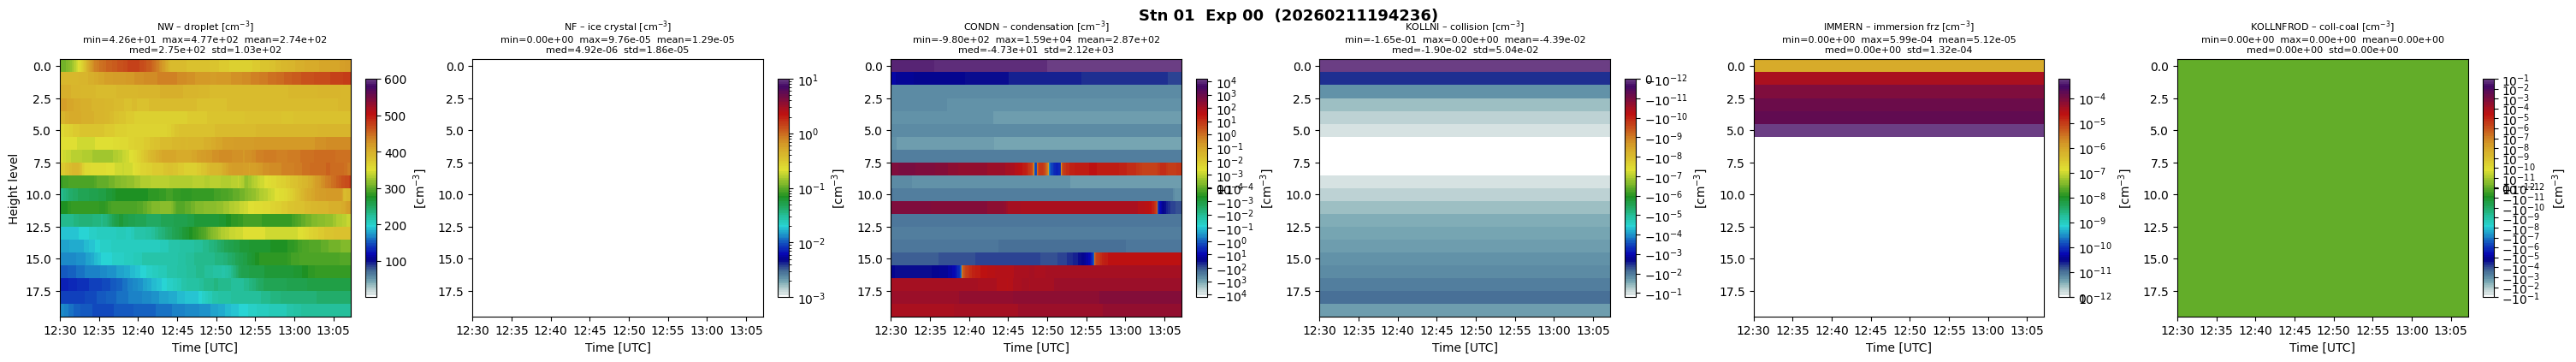

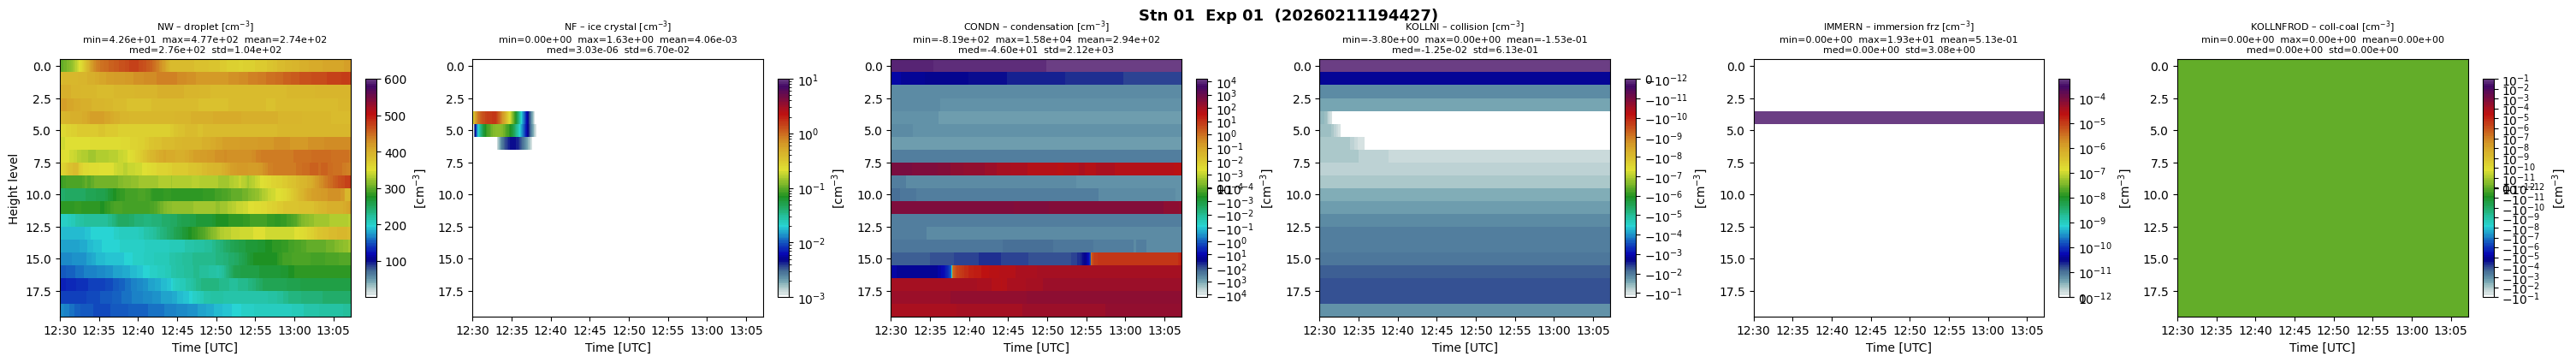

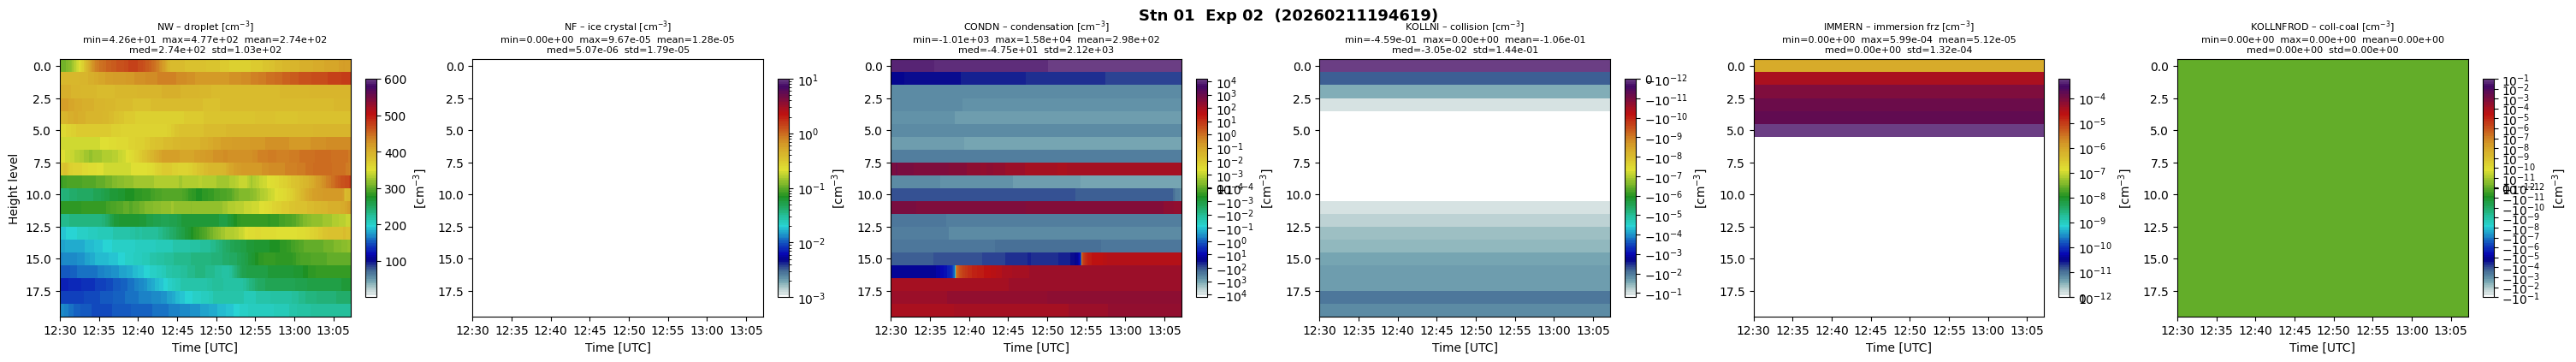

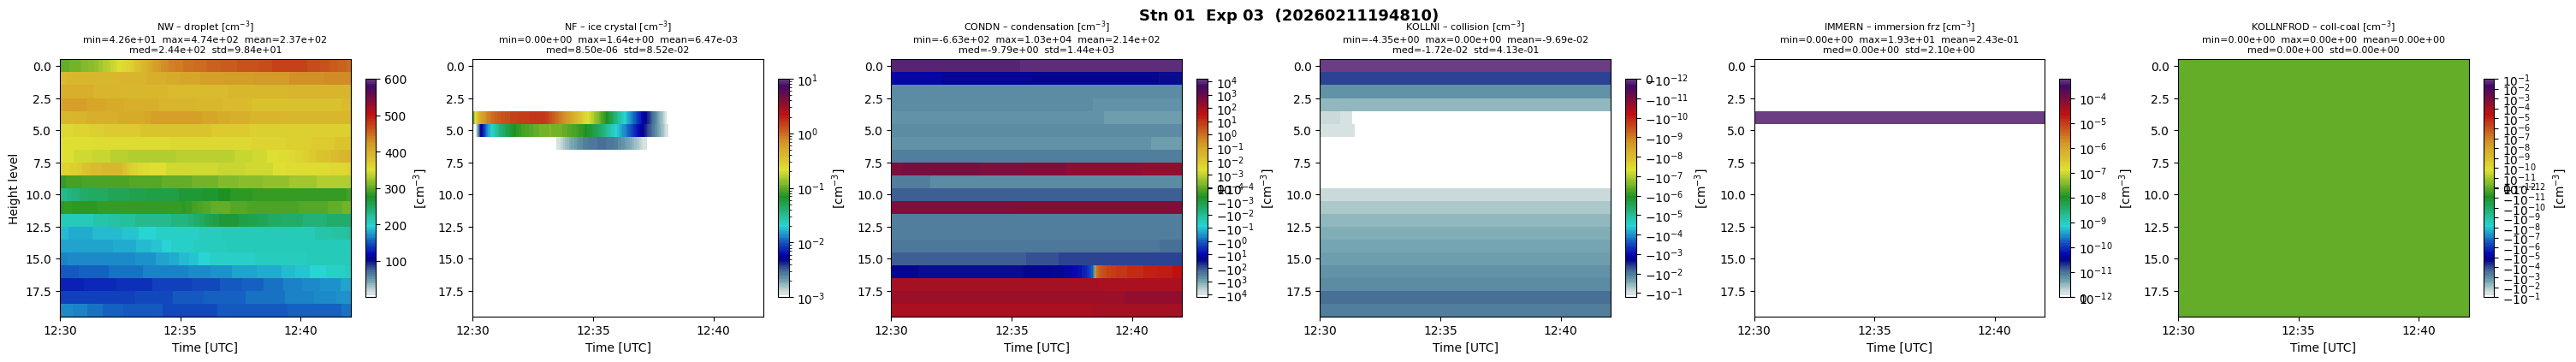

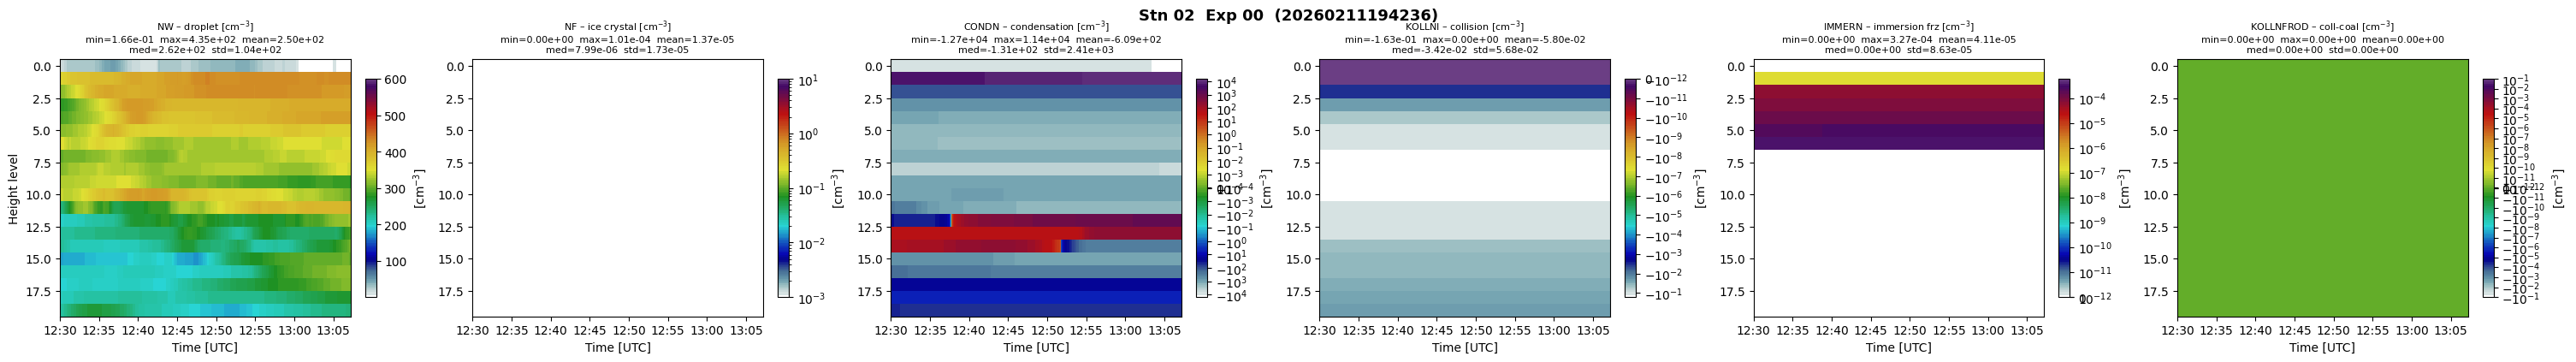

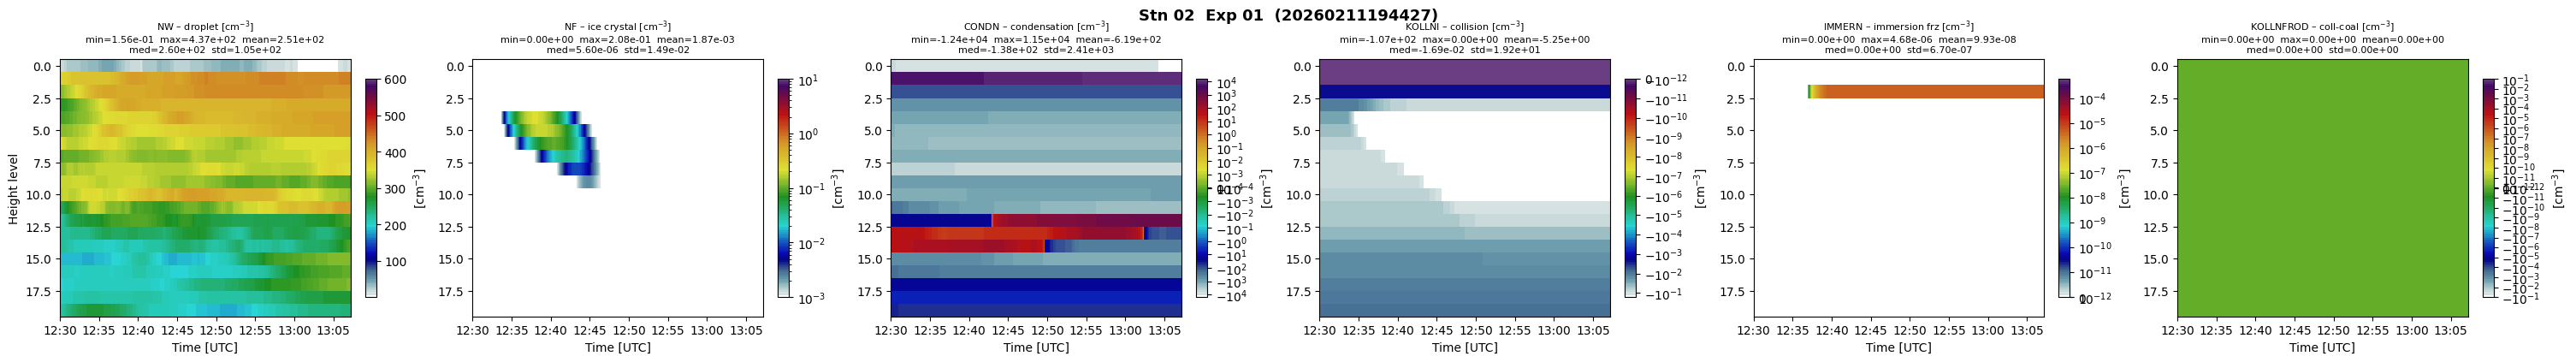

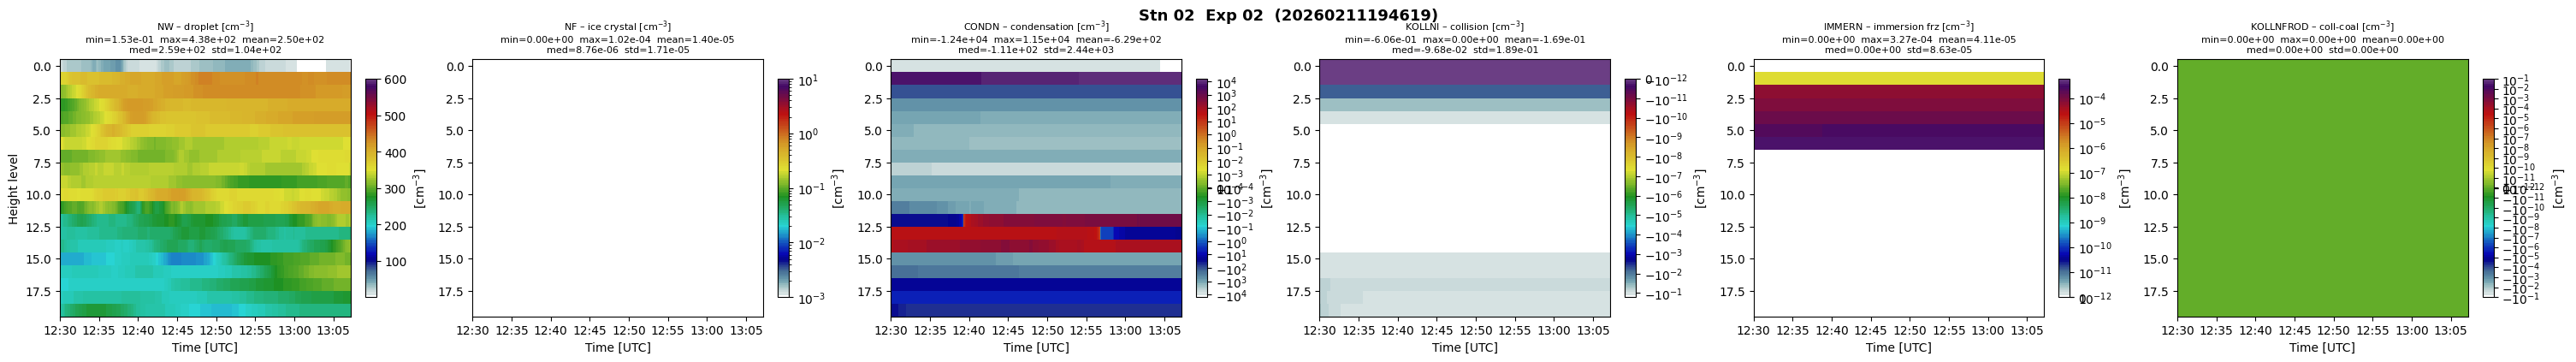

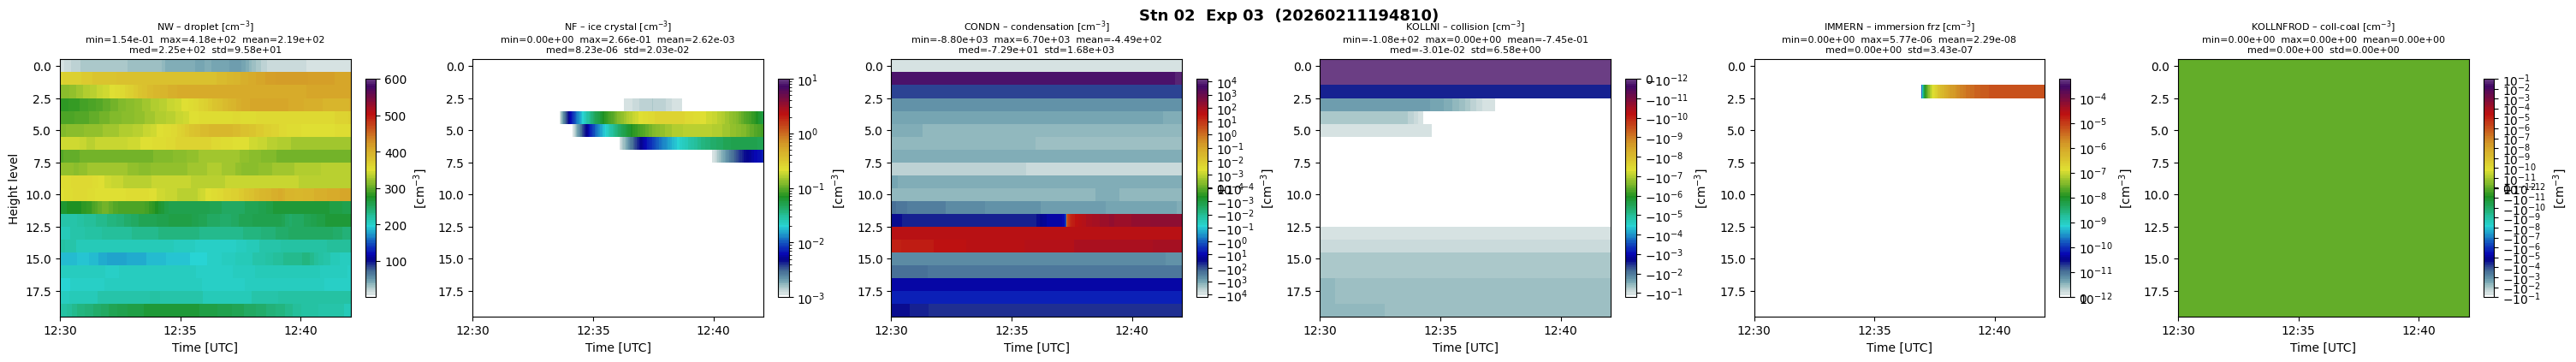

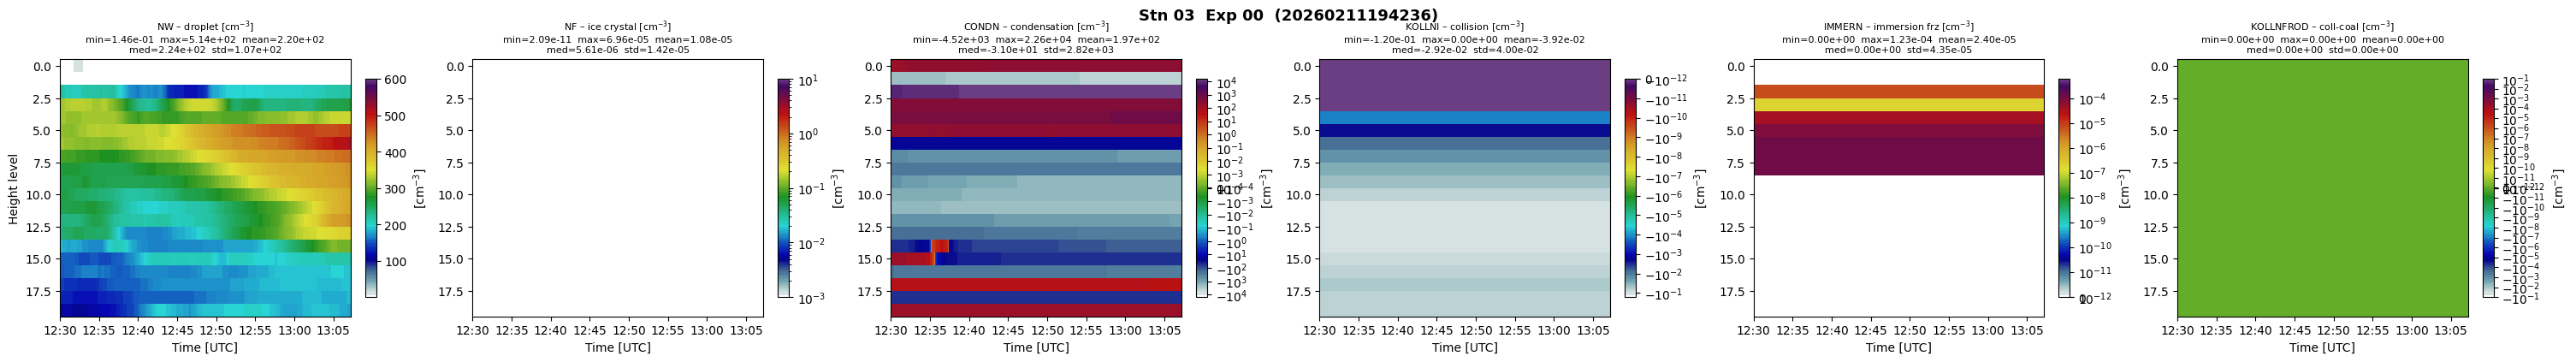

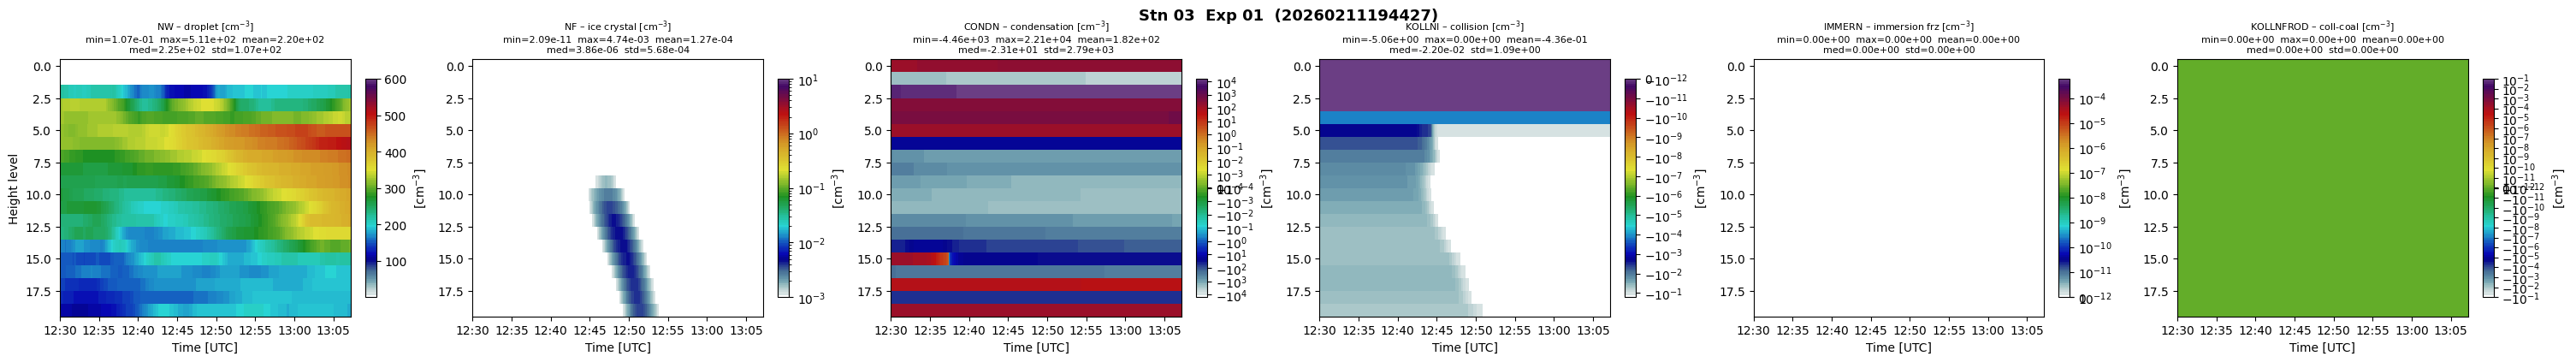

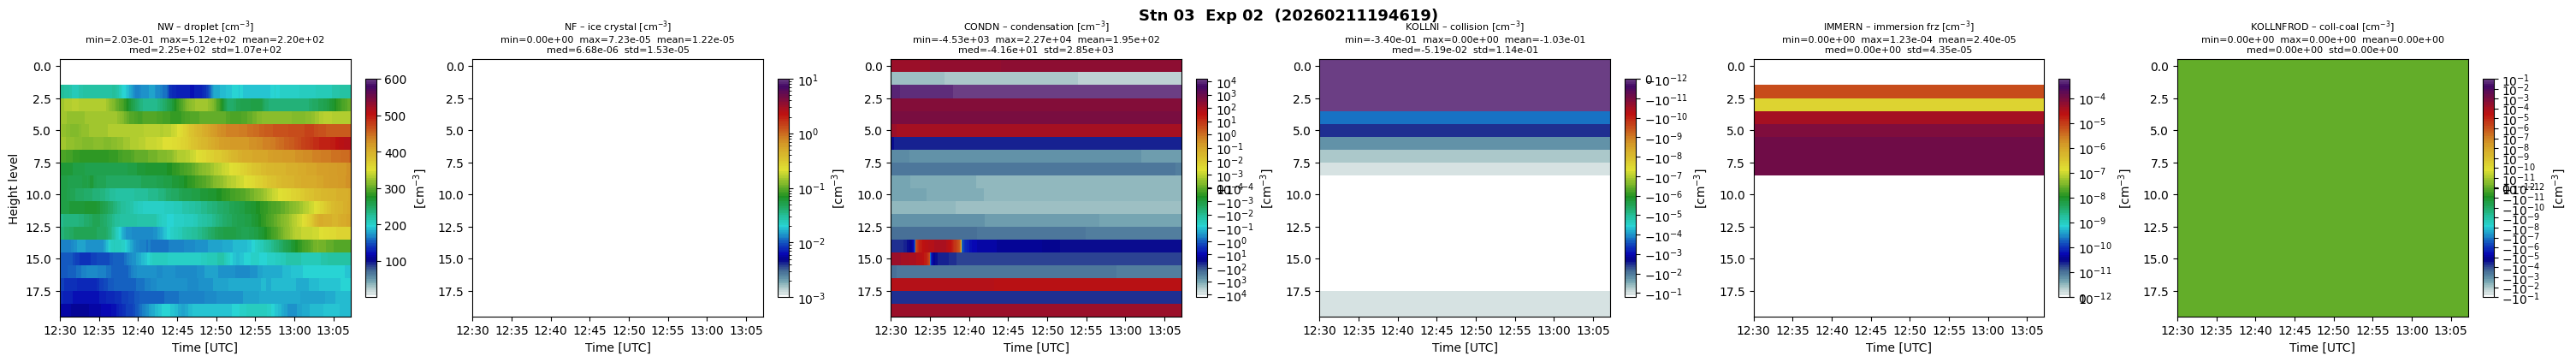

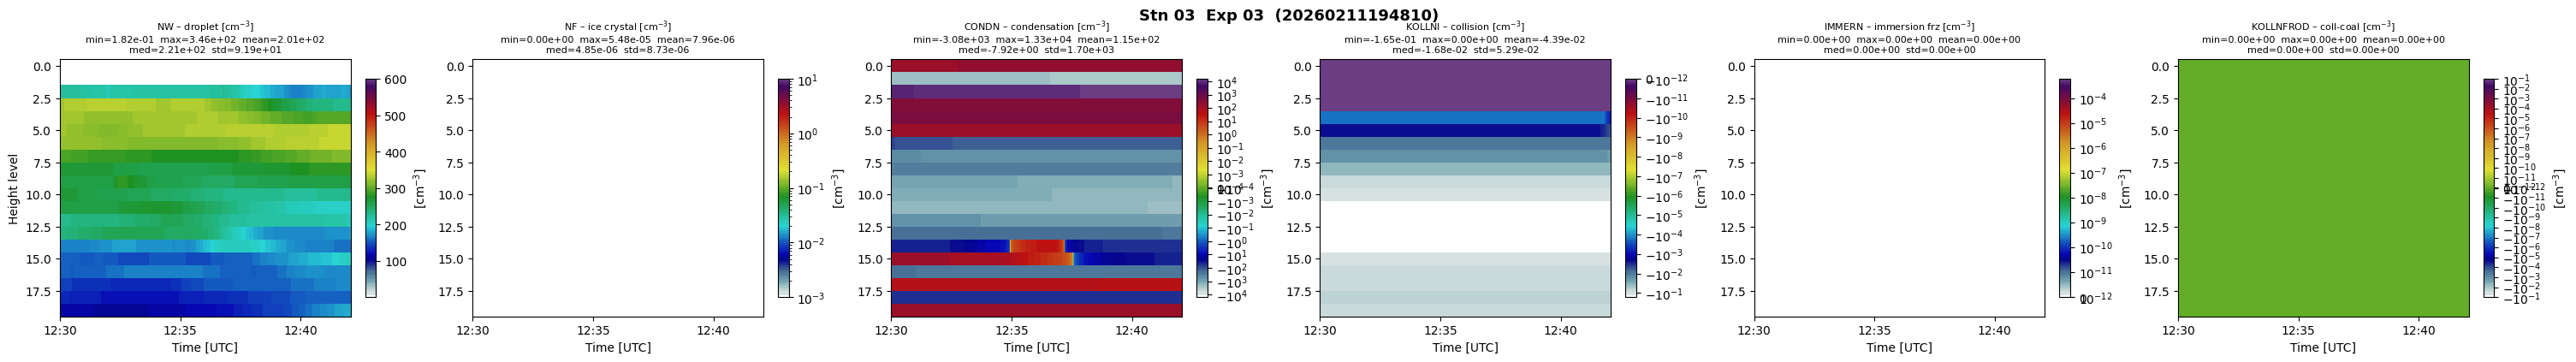

In [10]:
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)

plot_kw = dict(x="time", y="height_level", cmap=new_jet3_soft,
               add_colorbar=False, add_labels=False)

n_vars = len(var_config)

for nc_path in nc_files:
    info = parse_nc_filename(nc_path)
    # if info['experiment'] != 3: continue
    bulk = load_and_compute_bulk(nc_path)
    unit = bulk.attrs["unit"]
    title = f"Stn {info['station']:02d}  Exp {info['experiment']:02d}  ({info['timestamp']})"

    fig, axes = plt.subplots(1, n_vars, figsize=(n_vars * 5, 4), constrained_layout=True)

    for idx, (vname, _, _, _, vlabel, norm_kw) in enumerate(var_config):
        ax = axes[idx]
        pcm = bulk[vname].plot.pcolormesh(ax=ax, **norm_kw, **plot_kw)

        # stats for 2nd title row
        d = bulk[vname].values.ravel()
        d = d[np.isfinite(d)]
        stats = (f"min={d.min():.2e}  max={d.max():.2e}  mean={d.mean():.2e}\n"
                 f"med={np.median(d):.2e}  std={d.std():.2e}")
        ax.set_title(f"{vlabel} [{unit}]\n{stats}", fontsize=8)

        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.set_xlabel("Time [UTC]")
        ax.set_xlim(np.datetime64("2023-01-25T12:30:00"), None)
        if idx == 0:
            ax.set_ylabel("Height level")

        fig.colorbar(pcm, ax=ax, label=f"[{unit}]", shrink=0.85)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.show()

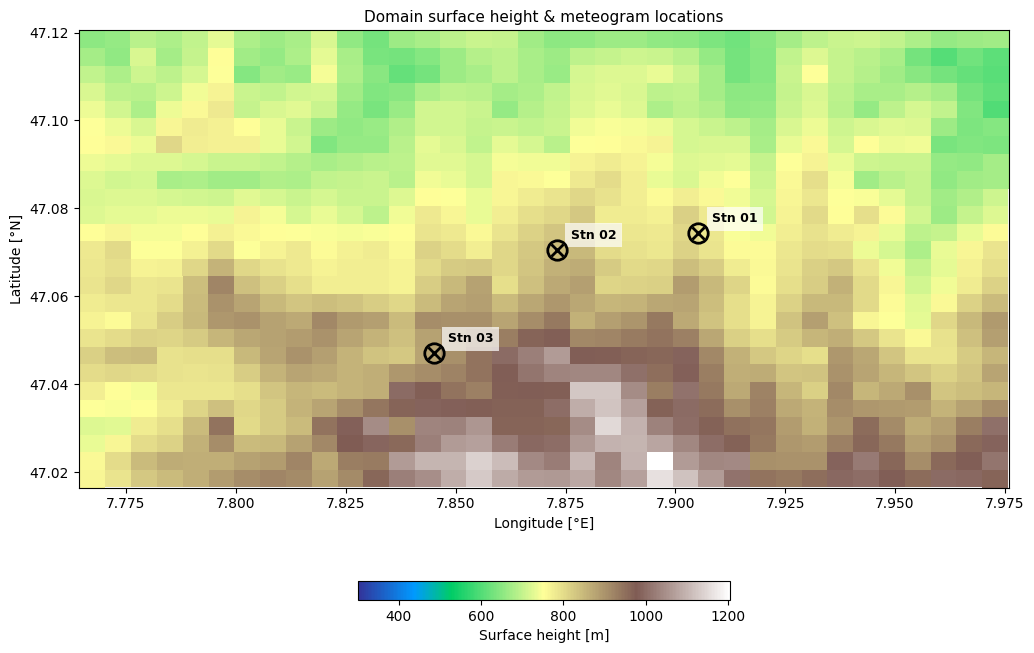

In [ ]:
from utilities.init_common import get_station_coords_from_cfg

meta_file = data_dir / f"{cs_run}.json"
station_coords = get_station_coords_from_cfg(str(meta_file))
# unique station IDs from the discovered files
station_ids = sorted({parse_nc_filename(f)["station"] for f in nc_files})

fig, ax_map = plt.subplots(figsize=(12, 9))
pm = ax_map.pcolormesh(lon2D, lat2D, hsurf, cmap="terrain", vmin=300, shading="auto")
fig.colorbar(pm, ax=ax_map, label="Surface height [m]",
             orientation="horizontal", shrink=0.4, pad=0.08)

for sid in station_ids:
    key = f"{sid:02d}" if isinstance(sid, int) else str(sid)
    if key not in station_coords:
        continue
    slat, slon = station_coords[key]
    ax_map.plot(slon, slat, "o", ms=14, mfc="none", mec="k", mew=2, zorder=5)
    ax_map.plot(slon, slat, "x", ms=9, mew=2, color="k", zorder=6)
    ax_map.annotate(f"Stn {key}", (slon, slat), textcoords="offset points",
                    xytext=(10, 8), fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax_map.set_xlabel("Longitude [°E]")
ax_map.set_ylabel("Latitude [°N]")
ax_map.set_title("Domain surface height & meteogram locations", fontsize=11)
ax_map.set_aspect("equal")
ax_map.set_anchor("C")


In [ ]:
info

{'station': 3,
 'experiment': 3,
 'timestamp': '20260211194810',
 'path': PosixPath('/Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260211_194236/M_03_03_20260211194810.nc')}

True